Setup and Imports

In [1]:
# Uncomment the line below to install required packages if you are in a new environment like Colab
# !pip install -q transformers peft torch pandas numpy matplotlib seaborn scikit-learn tqdm requests

import os
import requests
import random
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoModel, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Set device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {DEVICE}")

# Set styling for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

✅ Using device: cuda


Configuration

In [4]:
# --- MODEL CONFIGURATION ---
MODEL_NAME = "facebook/esm2_t33_650M_UR50D"
LORA_RANK = 8
LORA_ALPHA = 16
LORA_DROPOUT = 0.1
PROJECTED_SIZE = 256
DROPOUT = 0.1

# --- WEIGHTS CONFIGURATION ---
HF_WEIGHTS_URL = "https://huggingface.co/Harshit494/BALM-PPI/resolve/main/best_model_fold_1.pth"
LOCAL_WEIGHTS_PATH = "best_model_fold_1.pth"
USE_REMOTE = True # Set to False if you want to use a local weights file directly

# --- PKD BOUNDS (CRUCIAL FOR SCALING) ---
# Ensure these match the minimum and maximum 'Y' values from your ORIGINAL training data
PKD_LOWER_BOUND = 1.0  
PKD_UPPER_BOUND = 16.0 

print(f"✅ Configuration loaded. pKd bounds set to[{PKD_LOWER_BOUND}, {PKD_UPPER_BOUND}]")

✅ Configuration loaded. pKd bounds set to[1.0, 16.0]


Model Architecture

In [5]:
class BALMProjectionHead(nn.Module):
    def __init__(self, embedding_size, projected_size, projected_dropout):
        super().__init__()
        self.protein_projection = nn.Linear(embedding_size, projected_size)
        self.proteina_projection = nn.Linear(embedding_size, projected_size)
        self.dropout = nn.Dropout(projected_dropout)
        self.loss_fn = nn.MSELoss()

    def forward(self, protein_embedding, proteina_embedding, labels=None):
        protein_embedding = self.dropout(protein_embedding)
        proteina_embedding = self.dropout(proteina_embedding)
        
        protein_projected = self.protein_projection(protein_embedding)
        proteina_projected = self.proteina_projection(proteina_embedding)
        
        protein_projected = F.normalize(protein_projected, p=2, dim=1)
        proteina_projected = F.normalize(proteina_projected, p=2, dim=1)
        
        cosine_similarity = F.cosine_similarity(protein_projected, proteina_projected)
        cosine_similarity = torch.clamp(cosine_similarity, -0.9999, 0.9999)
        
        output = {"cosine_similarity": cosine_similarity}
        if labels is not None:
            output["loss"] = self.loss_fn(cosine_similarity, labels)
        return output

class BALMModel(nn.Module):
    def __init__(self):
        super().__init__()
        print("📥 Loading Base ESM-2 and Tokenizer...")
        self.tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        base_model = AutoModel.from_pretrained(MODEL_NAME)
        
        print("✨ Applying LoRA Configuration...")
        lora_config = LoraConfig(
            r=LORA_RANK,
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
            bias="none",
            task_type=TaskType.FEATURE_EXTRACTION,
            target_modules=["key", "query", "value"]
        )
        self.esm_model = get_peft_model(base_model, lora_config)
        self.embedding_size = self.esm_model.config.hidden_size
        
        self.projection_head = BALMProjectionHead(self.embedding_size, PROJECTED_SIZE, DROPOUT)
        self.cls_token = self.tokenizer.cls_token 

    def _get_esm_embeddings(self, sequences):
        # Pre-process sequences: Replace '|' with '<cls><cls>'
        processed_seqs =[s.replace('|', f"{self.cls_token}{self.cls_token}") for s in sequences]
        
        inputs = self.tokenizer(processed_seqs, return_tensors="pt", padding=True, truncation=True, max_length=1024)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        
        outputs = self.esm_model(**inputs)
        last_hidden = outputs.last_hidden_state
        
        # Mean Pooling
        mask = inputs['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()
        sum_embeddings = torch.sum(last_hidden * mask, dim=1)
        sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
        return (sum_embeddings / sum_mask).float()

    def forward(self, protein_seqs, proteina_seqs, labels=None):
        p1_emb = self._get_esm_embeddings(protein_seqs)
        p2_emb = self._get_esm_embeddings(proteina_seqs)
        return self.projection_head(p1_emb, p2_emb, labels)

print("✅ Model classes defined successfully.")

✅ Model classes defined successfully.


 Initialize Model and Load Weights

In [6]:
def download_weights(url, save_path):
    if not os.path.exists(save_path):
        print(f"⏳ Downloading weights from Hugging Face...")
        r = requests.get(url, allow_redirects=True)
        with open(save_path, 'wb') as f:
            f.write(r.content)
        print("✅ Download complete.")

model = BALMModel().to(DEVICE)

# Load Weights
path_to_load = LOCAL_WEIGHTS_PATH
if USE_REMOTE:
    download_weights(HF_WEIGHTS_URL, LOCAL_WEIGHTS_PATH)
    path_to_load = LOCAL_WEIGHTS_PATH

print(f"🔄 Loading weights from {path_to_load}...")
# strict=False allows loading even if there are slight prefix mismatches in LoRA naming
model.load_state_dict(torch.load(path_to_load, map_location=DEVICE), strict=False)
print("✅ BALM-PPI Pre-trained Model Loaded Successfully!")

📥 Loading Base ESM-2 and Tokenizer...


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t33_650M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✨ Applying LoRA Configuration...
⏳ Downloading weights from Hugging Face...
✅ Download complete.
🔄 Loading weights from best_model_fold_1.pth...


C:\Users\hs494\AppData\Local\Temp\ipykernel_46964\3857836119.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path_to_load, map_location

✅ BALM-PPI Pre-trained Model Loaded Successfully!


Load or Create Data

In [7]:
CSV_PATH = "Data.csv" 

def generate_dummy_data(num_samples=100):
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    data =[]
    for i in range(num_samples):
        seq1 = ''.join(random.choice(amino_acids) for _ in range(random.randint(40, 100)))
        seq2 = ''.join(random.choice(amino_acids) for _ in range(random.randint(40, 100)))
        pkd = round(random.uniform(1.0, 16.0), 2)
        data.append({'Target': seq1, 'proteina': seq2, 'Y': pkd})
    return pd.DataFrame(data)

if not os.path.exists(CSV_PATH):
    print(f"⚠️ {CSV_PATH} not found. Creating a synthetic dummy dataset for testing...")
    df = generate_dummy_data(100)
    df.to_csv(CSV_PATH, index=False)
else:
    df = pd.read_csv(CSV_PATH)

# Drop missing values
df = df.dropna(subset=['Target', 'proteina']).reset_index(drop=True)
if 'Y' in df.columns:
    df = df.dropna(subset=['Y']).reset_index(drop=True)

print(f"📊 Dataset ready with {len(df)} protein-protein pairs.")
display(df.head(3))

📊 Dataset ready with 100 protein-protein pairs.


,Target,proteina,Y
0,PIVQNLQGQMVHQAISPRTLNAWVKVVEEKAFSPEVIPMFSALSEG...,|MVNPTVFFDIAVDGEPLGRVSFELFADKVPKTAENFRALSTGEKG...,5.240998
1,PIVQNLQGQMVHQAISPRTLNAWVKVVEEKAFSPEVIPMFSALSEG...,|MVNPTVFFDIAVDGEPLGRVSFELFADKVPKTAENFRALSTGEKG...,5.299638
2,PIVQNLQGQMVHQAISPRTLNAWVKVVEEKAFSPEVIPMFSALSEG...,|MVNPTVFFDIAVDGEPLGRVSFELFADKVPKTAENFRALSTGEKG...,4.830514


Zero-Shot Inference

🚀 RUNNING ZERO-SHOT INFERENCE


Zero-Shot Predicting:   0%|          | 0/100 [00:00<?, ?it/s]

⏱️ Time taken: 12.24 seconds

📊 ZERO-SHOT PERFORMANCE:
RMSE:     1.1424
Pearson:  0.8368
Spearman: 0.8471


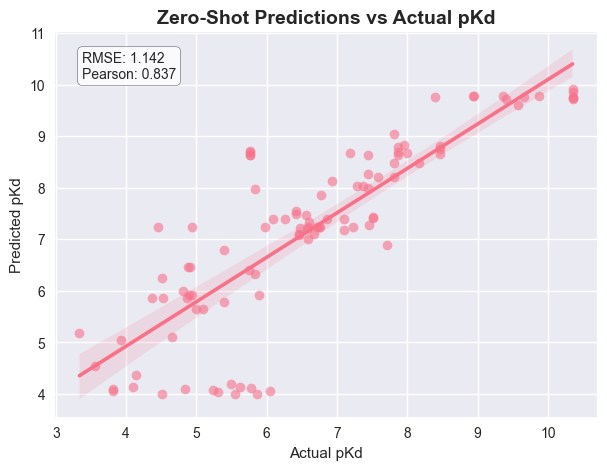

In [8]:
print("="*50)
print("🚀 RUNNING ZERO-SHOT INFERENCE")
print("="*50)

model.eval()
zero_shot_preds =[]
labels_list =[]

start_time = time.time()
with torch.no_grad():
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Zero-Shot Predicting"):
        # Explicit named arguments to avoid positional errors
        output = model(protein_seqs=[str(row['Target'])], proteina_seqs=[str(row['proteina'])])
        cos_sim = output['cosine_similarity'].item()
        
        # De-scale: Cosine Sim [-1, 1] -> pKd[PKD_LOWER, PKD_UPPER]
        pkd_pred = ((cos_sim + 1) / 2) * (PKD_UPPER_BOUND - PKD_LOWER_BOUND) + PKD_LOWER_BOUND
        zero_shot_preds.append(pkd_pred)
        
        if 'Y' in df.columns:
            labels_list.append(row['Y'])

df['ZeroShot_Prediction'] = zero_shot_preds
print(f"⏱️ Time taken: {time.time() - start_time:.2f} seconds")

# --- Evaluate Zero-Shot ---
if 'Y' in df.columns:
    y_true = np.array(labels_list)
    y_pred_zs = np.array(zero_shot_preds)
    
    rmse_zs = np.sqrt(mean_squared_error(y_true, y_pred_zs))
    pearson_zs = pearsonr(y_true, y_pred_zs)[0]
    spearman_zs = spearmanr(y_true, y_pred_zs)[0]
    
    print("\n📊 ZERO-SHOT PERFORMANCE:")
    print(f"RMSE:     {rmse_zs:.4f}")
    print(f"Pearson:  {pearson_zs:.4f}")
    print(f"Spearman: {spearman_zs:.4f}")

    plt.figure(figsize=(7, 5))
    sns.regplot(x=y_true, y=y_pred_zs, scatter_kws={'alpha':0.6})
    plt.title("Zero-Shot Predictions vs Actual pKd", fontsize=14, fontweight='bold')
    plt.xlabel("Actual pKd")
    plt.ylabel("Predicted pKd")
    
    metrics_text = f"RMSE: {rmse_zs:.3f}\nPearson: {pearson_zs:.3f}"
    plt.text(0.05, 0.95, metrics_text, transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.show()
else:
    print("\n⚠️ No ground truth ('Y' column) found. Metrics skipped.")

Few-Shot Setup and Training

In [9]:
if 'Y' not in df.columns:
    print("❌ Cannot run Few-Shot Training because 'Y' (labels) column is missing in the dataset.")
else:
    print("="*50)
    print("🔬 RUNNING FEW-SHOT FINE-TUNING")
    print("="*50)
    
    # --- Few-Shot Hyperparameters ---
    FEW_SHOT_EPOCHS = 10
    FEW_SHOT_LR = 1e-4
    TRAIN_RATIO = 0.3 # Use 30% of data for few-shot training
    
    # Split Data
    train_df, test_df = train_test_split(df, train_size=TRAIN_RATIO, random_state=42)
    print(f"Training on {len(train_df)} samples. Testing on {len(test_df)} samples.")
    
    class FewShotDataset(Dataset):
        def __init__(self, dataframe):
            self.df = dataframe.reset_index(drop=True)
        def __len__(self): 
            return len(self.df)
        def __getitem__(self, idx):
            row = self.df.iloc[idx]
            # Convert pKd to Cosine Similarity Target[-1, 1]
            scaled_label = ((row['Y'] - PKD_LOWER_BOUND) / (PKD_UPPER_BOUND - PKD_LOWER_BOUND)) * 2 - 1
            return {
                "p1": str(row["Target"]),
                "p2": str(row["proteina"]),
                "label": torch.tensor(scaled_label, dtype=torch.float32)
            }
            
    train_loader = DataLoader(FewShotDataset(train_df), batch_size=1, shuffle=True)
    
    # Setup optimizer (Train all trainable parameters, which includes LoRA + Projection Head)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = AdamW(trainable_params, lr=FEW_SHOT_LR, weight_decay=0.01)
    
    model.train()
    for epoch in range(FEW_SHOT_EPOCHS):
        total_loss = 0.0
        for batch in train_loader:
            optimizer.zero_grad()
            
            # Explicit named arguments passed to model
            outputs = model(
                protein_seqs=batch["p1"], 
                proteina_seqs=batch["p2"], 
                labels=batch["label"].to(DEVICE)
            )
            
            loss = outputs["loss"]
            loss.backward()
            
            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()
            
            total_loss += loss.item()
            
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{FEW_SHOT_EPOCHS}] - Loss: {avg_loss:.4f}")
        
    print("✅ Few-Shot Fine-Tuning Complete!")

🔬 RUNNING FEW-SHOT FINE-TUNING
Training on 30 samples. Testing on 70 samples.
Epoch [1/10] - Loss: 0.0259
Epoch [2/10] - Loss: 0.0110
Epoch [3/10] - Loss: 0.0090
Epoch [4/10] - Loss: 0.0088
Epoch [5/10] - Loss: 0.0082
Epoch [6/10] - Loss: 0.0075
Epoch [7/10] - Loss: 0.0072
Epoch [8/10] - Loss: 0.0075
Epoch [9/10] - Loss: 0.0065
Epoch [10/10] - Loss: 0.0088
✅ Few-Shot Fine-Tuning Complete!


Few-Shot Evaluation & Comparison

🏆 FEW-SHOT TEST SET EVALUATION


Few-Shot Testing:   0%|          | 0/70 [00:00<?, ?it/s]


📊 PERFORMANCE ON TEST SET (70 samples):
Metric          | Zero-Shot    | Few-Shot    
---------------------------------------------
RMSE            | 1.1222       | 0.7848      
Pearson R       | 0.8510       | 0.8959      


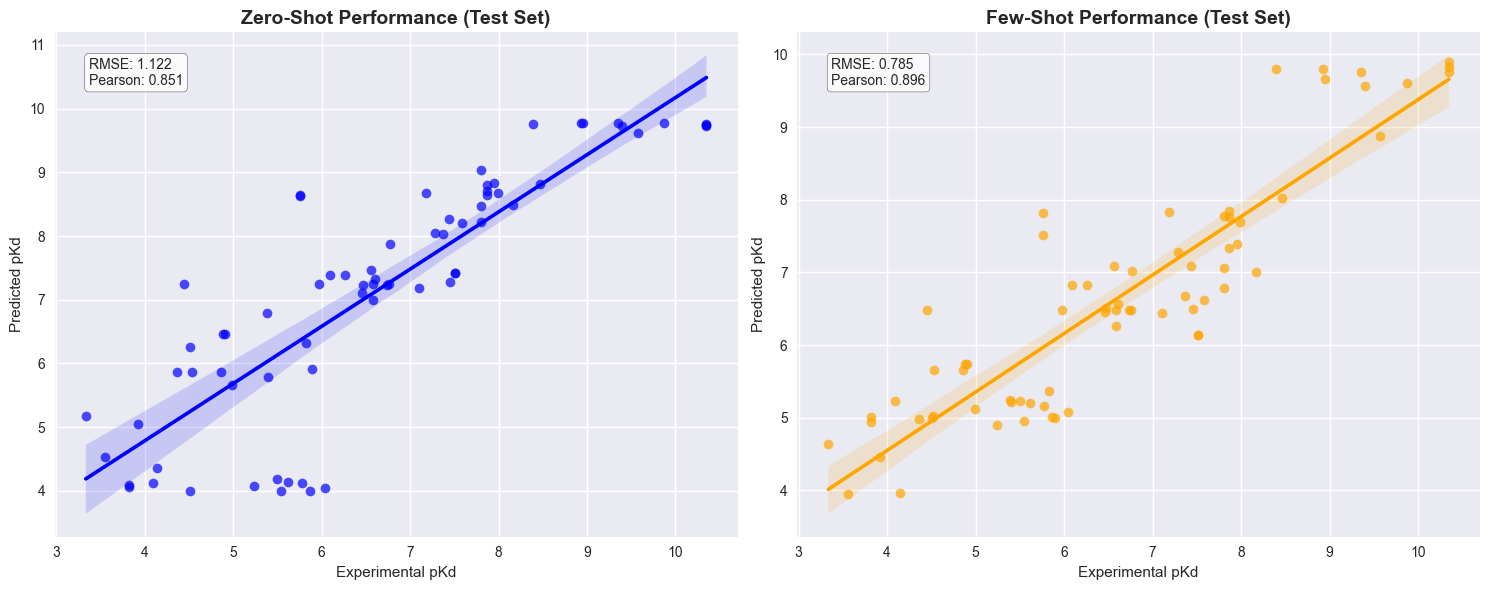


💾 Final test set predictions saved to 'Final_Test_Predictions.csv'


In [10]:
if 'Y' in df.columns:
    print("="*50)
    print("🏆 FEW-SHOT TEST SET EVALUATION")
    print("="*50)
    
    model.eval()
    few_shot_preds =[]
    test_labels =[]
    
    with torch.no_grad():
        for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Few-Shot Testing"):
            output = model(protein_seqs=[str(row['Target'])], proteina_seqs=[str(row['proteina'])])
            cos_sim = output['cosine_similarity'].item()
            
            pkd_pred = ((cos_sim + 1) / 2) * (PKD_UPPER_BOUND - PKD_LOWER_BOUND) + PKD_LOWER_BOUND
            few_shot_preds.append(pkd_pred)
            test_labels.append(row['Y'])
            
    # Compute Few-Shot Metrics
    y_true_test = np.array(test_labels)
    y_pred_fs = np.array(few_shot_preds)
    
    rmse_fs = np.sqrt(mean_squared_error(y_true_test, y_pred_fs))
    pearson_fs = pearsonr(y_true_test, y_pred_fs)[0]
    spearman_fs = spearmanr(y_true_test, y_pred_fs)[0]
    
    # Get the corresponding Zero-Shot predictions for the SAME test set for direct comparison
    # We use the indices from test_df to locate the Zero-Shot predictions calculated in Cell 6
    test_indices = test_df.index
    y_pred_zs_test = np.array([zero_shot_preds[i] for i in test_indices])
    rmse_zs_test = np.sqrt(mean_squared_error(y_true_test, y_pred_zs_test))
    pearson_zs_test = pearsonr(y_true_test, y_pred_zs_test)[0]

    print(f"\n📊 PERFORMANCE ON TEST SET ({len(test_df)} samples):")
    print(f"{'Metric':<15} | {'Zero-Shot':<12} | {'Few-Shot':<12}")
    print("-" * 45)
    print(f"{'RMSE':<15} | {rmse_zs_test:<12.4f} | {rmse_fs:<12.4f}")
    print(f"{'Pearson R':<15} | {pearson_zs_test:<12.4f} | {pearson_fs:<12.4f}")
    
    # --- Plot Comparison ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Zero-Shot Plot
    sns.regplot(x=y_true_test, y=y_pred_zs_test, ax=ax1, scatter_kws={'alpha':0.7}, color='blue')
    ax1.set_title("Zero-Shot Performance (Test Set)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Experimental pKd")
    ax1.set_ylabel("Predicted pKd")
    ax1.text(0.05, 0.95, f"RMSE: {rmse_zs_test:.3f}\nPearson: {pearson_zs_test:.3f}", 
             transform=ax1.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Few-Shot Plot
    sns.regplot(x=y_true_test, y=y_pred_fs, ax=ax2, scatter_kws={'alpha':0.7}, color='orange')
    ax2.set_title("Few-Shot Performance (Test Set)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Experimental pKd")
    ax2.set_ylabel("Predicted pKd")
    ax2.text(0.05, 0.95, f"RMSE: {rmse_fs:.3f}\nPearson: {pearson_fs:.3f}", 
             transform=ax2.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()
    
    # Save the final predictions to CSV
    test_df_results = test_df.copy()
    test_df_results['FewShot_Prediction'] = few_shot_preds
    test_df_results.to_csv("Final_Test_Predictions.csv", index=False)
    print("\n💾 Final test set predictions saved to 'Final_Test_Predictions.csv'")